In [41]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df=sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [43]:

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


as it show there are three categorycal datatype our model only understands numerber so we need to change these category into numbers for that we need to understand encoding 

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)

Text(0.5, 1.0, 'Price distribution (log-transformed)')

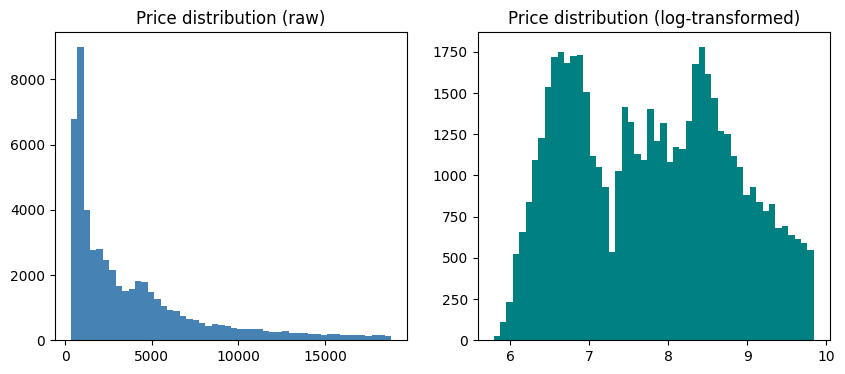

In [45]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='steelblue')
plt.title('Price distribution (raw)')
# You'll see: heavily right-skewed (most diamonds cheap,
#             a few very expensive ones pull the tail right)

plt.subplot(1, 2, 2)
plt.hist(np.log(df['price']), bins=50, color='teal')
plt.title('Price distribution (log-transformed)')

In [46]:
x=df_encoded.drop(columns=['price'])# features = everything except prce columns 
y=df_encoded['price']#  target = only price 

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(f"training rows:{len(X_train)}")
print(f"testing rows:{len(X_test)}")

training rows:43152
testing rows:10788


In [50]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

print("model trained succesfully")

y_pred=lr.predict(X_test)


model trained succesfully


In [55]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

r2_lr=r2_score(y_test,y_pred)
mae_lr=mean_squared_error(y_test,y_pred)

print(f"linear regression R2:{r2_lr:.3f}")
print(f"linear regression MAE: $ {mae_lr:0f}")

linear regression R2:0.919
linear regression MAE: $ 1288705.477852
